# Empirical Distributions

Notebooks 01–03 described parametric population models, empirical moments and inferential uncertainty. This notebook asks what can be learned directly from a finite sample without specifying its entire distribution. Histograms, density estimates and the empirical CDF lead to QQ plots, which reconnect empirical observations with parametric assumptions.

I use simulations from known populations so that each empirical description can be compared with its target. The final sections use the loss convention from Notebook 00 to obtain empirical VaR and ES, preserving the population-versus-sample distinction. Notebook 05 then applies these descriptions to observed equity and bond returns.

Throughout these examples, $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ is a simplifying sampling framework. Financial returns need not be fully IID because dependence over time can matter. The time-series notebooks address that distinction.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from finstats.empirical import empirical_cdf, empirical_quantile, qq_data
from finstats.risk import historical_var, historical_es, student_t_var, student_t_es


## 1. From Population to Observed Sample

The population distribution is not directly observed. The values $x_1,\ldots,x_n$ are one finite realization, whose empirical shape and moments generally differ from population quantities. Simulation makes this distinction visible because the generating population is known. With actual data, a proposed parametric distribution remains an assumption.

Nonparametric methods avoid choosing a distributional family, but still face finite-sample uncertainty. Their smoothing and quantile conventions also need to be specified.

## 2. Empirical Distribution

Histograms and kernel density estimates describe the observed sample through different smoothing choices.

### Histogram

**Definition: histogram.** A histogram divides the observation range into bins. If a bin has width $\Delta$ and contains $n_j$ observations, its density height is $n_j/(n\Delta)$. The rectangle's area is the empirical fraction $n_j/n$. Its shape depends on the bin boundaries and widths.

### Kernel Density Estimation

**Definition: kernel.** Write a symmetric kernel density as $K(y;b)$, where $b>0$ is its bandwidth. A Gaussian kernel is
$$K(y;b)=\frac1{b\sqrt{2\pi}}\exp\left(-\frac{y^2}{2b^2}\right).$$
**Definition: kernel density estimate.** Placing a kernel at each observation and averaging gives
$$\hat f_b(y)=\frac1n\sum_{i=1}^n K(y-x_i;b)
=\frac1{nb}\sum_{i=1}^n K_0\left(\frac{y-x_i}{b}\right),$$
where $K_0$ is a unit-bandwidth kernel. The kernel integrates to one, so the estimate is also a density.

A smaller bandwidth reduces smoothing bias but increases variability. A larger bandwidth reduces local variability while potentially obscuring population features. This is the bias–variance trade-off in a density estimate, rather than a choice between different generating populations.

For illustration, I simulate 250 IID observations from $0.6N(-1,0.5^2)+0.4N(1.5,0.7^2)$ with seed 406. The small/default/large bandwidth comparison uses 0.1, 1 and 100 times SciPy's Scott factor. This default differs from R's rule. The known density and histogram provide reference points.

Multiplier 0.1: bandwidth 0.0440
Multiplier 1: bandwidth 0.4401
Multiplier 100: bandwidth 44.0143


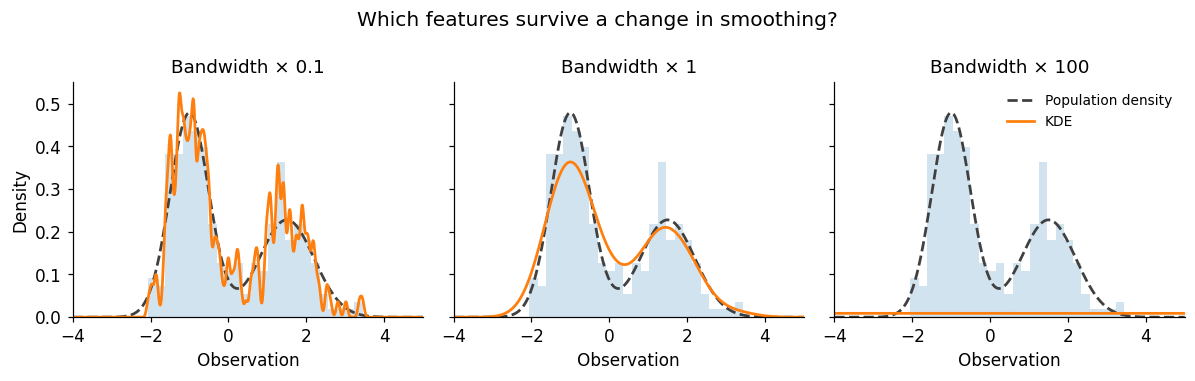

In [2]:
rng_kde = np.random.default_rng(406)
components = rng_kde.random(250) < .6
mixture_sample = rng_kde.normal(np.where(components, -1, 1.5), np.where(components, .5, .7))
kde_grid = np.linspace(-4, 5, 801)
mixture_density = .6*stats.norm.pdf(kde_grid, loc=-1, scale=.5)+.4*stats.norm.pdf(kde_grid, loc=1.5, scale=.7)
default_kde = stats.gaussian_kde(mixture_sample)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
for ax, multiplier in zip(axes, (.1, 1, 100)):
    kde = stats.gaussian_kde(mixture_sample, bw_method=default_kde.factor*multiplier)
    ax.hist(mixture_sample, bins=25, density=True, alpha=.2)
    ax.plot(kde_grid, mixture_density, "--", color="0.25", label="Population density")
    ax.plot(kde_grid, kde(kde_grid), color="C1", label="KDE")
    ax.set(xlabel="Observation", title=f"Bandwidth × {multiplier:g}", xlim=(-4, 5))
    print(f"Multiplier {multiplier:g}: bandwidth {np.sqrt(kde.covariance[0,0]):.4f}")
axes[0].set_ylabel("Density")
axes[-1].legend(fontsize=9)
fig.suptitle("Which features survive a change in smoothing?")
fig.tight_layout()
plt.show()

The smallest bandwidth produces peaks tied closely to individual observations. The largest smooths away both population groups. Neither local fluctuations nor an exceptionally smooth curve should be treated as evidence of the true shape. A KDE also does not reveal unobserved extreme outcomes reliably.

## 3. Empirical Cumulative Distribution

The empirical CDF and its inverse describe cumulative sample frequencies and quantiles without selecting a parametric family.

### Empirical Cumulative Distribution Function

**Definition: empirical CDF.** The ECDF counts the fraction of observations at or below a threshold:
$$\hat F_n(x)=\frac1n\sum_{i=1}^n I(x_i\le x).$$
It is right-continuous and combines jumps at tied observations. Even for a continuous population, its empirical distribution places mass on observed values.

Under IID sampling, at a fixed $x$,
$$E[\hat F_n(x)]=F(x),\qquad \operatorname{Var}[\hat F_n(x)]=\frac{F(x)(1-F(x))}{n}.$$
The expectation identifies its population target and the variance describes sampling uncertainty. Pointwise consistency follows as $n$ grows. These results do not require a finite population mean, since the indicators are bounded.

### Empirical Quantiles and Inverse Empirical CDF

**Definition: empirical quantile.** The inverse ECDF gives the empirical quantile
$$\hat x_q=\inf\{x:\hat F_n(x)\ge q\}=x_{(\lceil nq\rceil)},\qquad0<q<1,$$
where $x_{(j)}$ is the $j$th ordered observation. This convention does not interpolate. The library returns the minimum and maximum for its endpoint conventions $q=0$ and $q=1$.

For illustration, I use a Cauchy population at $n=5,100,1000$, with nested IID samples and seed 0. The same figure shows the ECDF and its inverse at $q=.75$, whose population quantile is one. Full sample ranges are printed because the common plotting window omits extreme observations.

n=5: full range -5.015 to 5.379, outside window: 0
n=100: full range -135.080 to 81.215, outside window: 2


n=1000: full range -808.531 to 234.208, outside window: 72


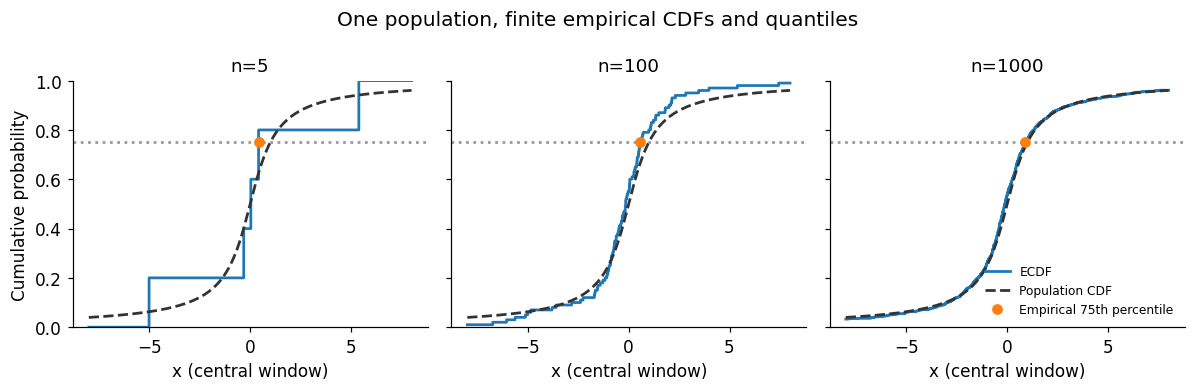

,n,Population 75th percentile,Empirical 75th percentile
0,5,1.0,0.4124
1,100,1.0,0.5731
2,1000,1.0,0.9065


In [3]:
cauchy_sample = np.random.default_rng(0).standard_t(1, size=1000)
cdf_grid = np.linspace(-8, 8, 1501)
q, true_quantile = .75, 1.
quantile_rows = []
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for ax, n in zip(axes, (5, 100, 1000)):
    values = cauchy_sample[:n]
    estimate = empirical_quantile(values, q)
    ax.step(cdf_grid, empirical_cdf(values)(cdf_grid), where="post", label="ECDF")
    ax.plot(cdf_grid, stats.t.cdf(cdf_grid, 1), "--", color="0.2", label="Population CDF")
    ax.axhline(q, color="0.6", linestyle=":")
    ax.plot([estimate], [q], "o", color="C1", label="Empirical 75th percentile")
    ax.set(xlabel="x (central window)", title=f"n={n}", ylim=(0, 1))
    quantile_rows.append([n, true_quantile, estimate])
    print(f"n={n}: full range {values.min():.3f} to {values.max():.3f}, outside window: {np.sum(np.abs(values)>8)}")
axes[0].set_ylabel("Cumulative probability")
axes[-1].legend(fontsize=8, loc="lower right")
fig.suptitle("One population, finite empirical CDFs and quantiles")
fig.tight_layout()
plt.show()
display(pd.DataFrame(quantile_rows, columns=["n", "Population 75th percentile", "Empirical 75th percentile"]).round(4))

The Cauchy population has no finite mean, but its CDF and quantiles remain well defined. A larger sample can describe those population properties more closely, even when sample extremes remain large.

## 4. Quantile-Quantile Plots

**Definition: QQ plot.** A QQ plot compares empirical quantiles with theoretical quantiles from a candidate parametric distribution. For $q_i=(i-.5)/n$, the plotted points are

$$
\left(F_0^{-1}(q_i),x_{(i)}\right),\qquad i=1,\ldots,n.
$$

When the candidate agrees with the population, the points fluctuate around the identity line. Curvature can indicate a shape difference, while extreme order statistics are especially variable in finite samples.

### Comparing Empirical Quantiles with Parametric Models

The candidate need not be Gaussian. Any distribution with a quantile function can be used, with parameters specified in advance or estimated from data. QQ plots therefore connect an empirical description with parametric assumptions.

For illustration, I simulate 1000 IID Laplace observations with location zero and scale $1/\sqrt2$ using seed 409. I compare the same observations with Gaussian, Student-$t_5$, Laplace and standard skew-normal candidates. Parameters are fixed rather than fitted. The first three candidates have mean zero and variance one. The standard skew-normal uses location zero, scale one and shape three, which gives a nonzero mean and a different variance, as discussed in Notebook 01. Its departures therefore reflect both asymmetry and different moments.

The four panels use matching axes. The Laplace candidate is the known DGP, while the other panels show the consequences of comparing its empirical quantiles with different parametric models. Even the correct candidate has finite-sample tail deviations.

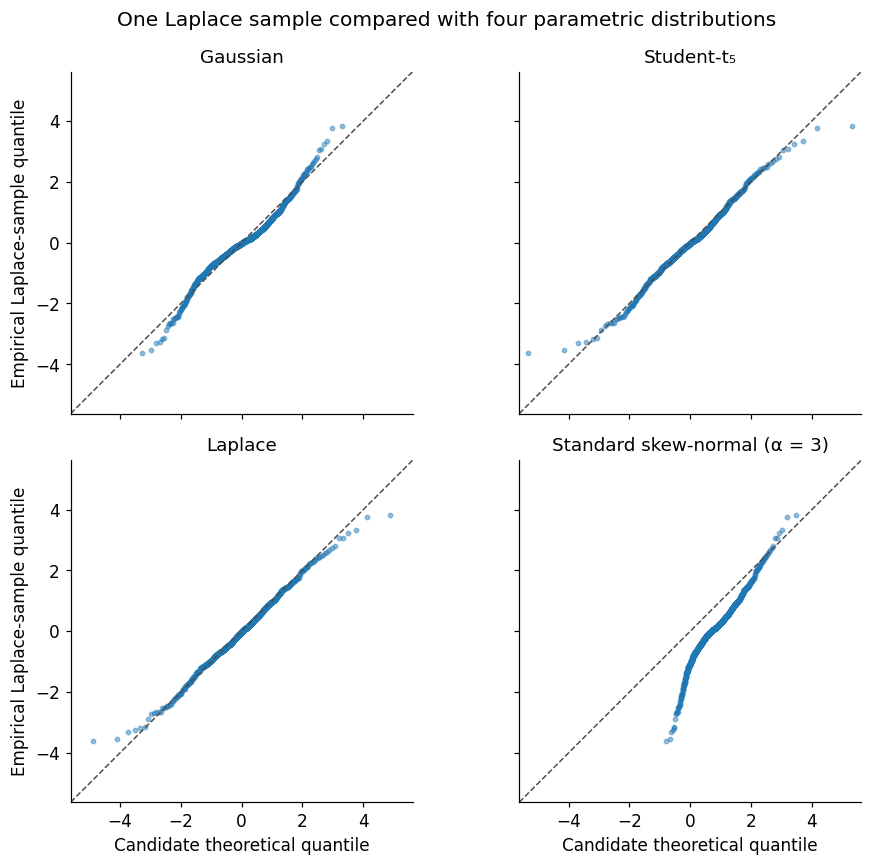

In [4]:
laplace_qq_sample = np.random.default_rng(409).laplace(0., 1/np.sqrt(2), size=1000)
qq_candidates = {"Gaussian": stats.norm(),
                 "Student-t₅": stats.t(5, scale=np.sqrt(3/5)),
                 "Laplace": stats.laplace(scale=1/np.sqrt(2)),
                 "Standard skew-normal (α = 3)": stats.skewnorm(3)}
qq_pairs = {name: qq_data(laplace_qq_sample, candidate) for name, candidate in qq_candidates.items()}
axis_limit = .3+max(np.max(np.abs(values)) for pair in qq_pairs.values() for values in pair)
fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
for ax, (name, (theoretical, empirical)) in zip(axes.flat, qq_pairs.items()):
    ax.scatter(theoretical, empirical, s=8, alpha=.45, color="C0")
    ax.plot([-axis_limit, axis_limit], [-axis_limit, axis_limit], "--", color="0.3", linewidth=1)
    ax.set(title=name, aspect="equal", xlim=(-axis_limit, axis_limit), ylim=(-axis_limit, axis_limit))
for ax in axes[:, 0]:
    ax.set_ylabel("Empirical Laplace-sample quantile")
for ax in axes[-1]:
    ax.set_xlabel("Candidate theoretical quantile")
fig.suptitle("One Laplace sample compared with four parametric distributions")
fig.tight_layout()
plt.show()


Although the observations were generated from Laplace, the Student-t comparison also lies close to the identity line over much of the observed range. Both candidates are symmetric and heavier-tailed than Gaussian, and their quantiles can be similar after matching mean and variance. Their far tails differ: Laplace tails decay exponentially, whereas Student-t tails decay polynomially. A finite sample contains few extreme observations, so these differences can be difficult to distinguish visually, even here with 1000 observations.

A QQ plot should therefore be read as a diagnostic of agreement, rather than identification of the true DGP. Similar-looking plots do not imply identical distributions. Tail departures also reflect sampling variability, and candidate parameters affect the comparison. Further model assessment may be needed before drawing conclusions, especially when the application depends on extreme outcomes.

The DGP is known here because the observations were simulated. With actual data, it remains unknown.

## 5. Empirical Tail Quantiles and Risk Estimates

**Definition: empirical VaR.** Observed losses give the inverse-ECDF threshold
$$\widehat{VaR}_\alpha=\hat F_{L,n}^{-1}(1-\alpha).$$
**Definition: historical ES.** The historical ES convention used here averages losses strictly above it:
$$\widehat{ES}_\alpha=
\frac{\sum_iL_iI(L_i>\widehat{VaR}_\alpha)}{\sum_iI(L_i>\widehat{VaR}_\alpha)}.$$
**Convention note.** This strict-exceedance average differs from integrated empirical ES, which can assign fractional weight at the quantile boundary. Its tail count need not equal $n\alpha$, and it is undefined if there are no exceedances.

For illustration, I use the loss population $L=5+2T_\nu$ with $(\nu,n)=(2,250),(20,250),(2,2500)$ and $\alpha=0.005$, using seed 415. The same threshold probability is estimated from populations with different tail shapes and sample sizes. The plots focus on the upper tail, with true and estimated risk values printed below.

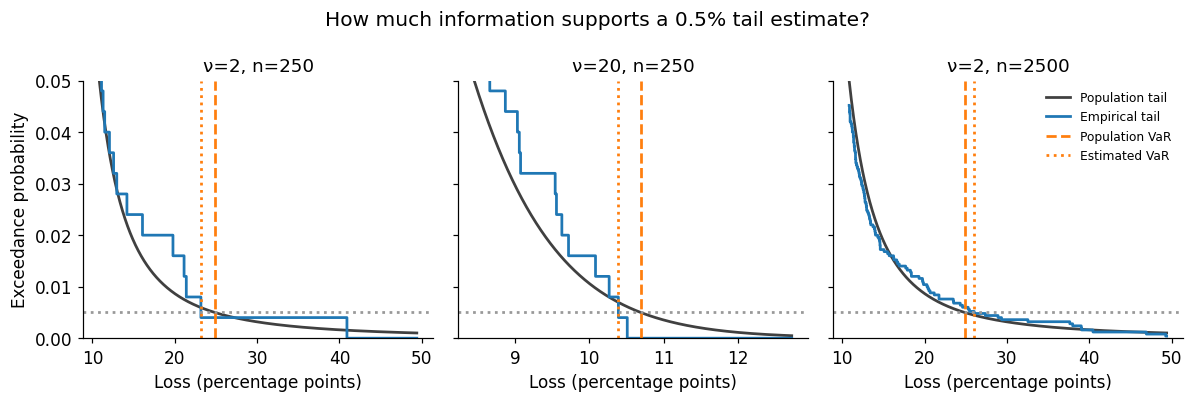

,df,n,true VaR,estimated VaR,true ES,estimated ES,strict tail count
0,2,250,24.8497,23.1611,44.8999,40.8992,1
1,20,250,10.6907,10.3893,11.5688,10.5095,1
2,2,2500,24.8497,26.0244,44.8999,40.3753,12


In [5]:
rng_tail = np.random.default_rng(415)
tail_rows = []
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True)
for ax, (df, n) in zip(axes, ((2, 250), (20, 250), (2, 2500))):
    losses = 5+2*rng_tail.standard_t(df, size=n)
    true_var = student_t_var(5, 2, df, .005)
    true_es = student_t_es(5, 2, df, .005)
    estimate_var = historical_var(losses, .005)
    estimate_es = historical_es(losses, .005)
    grid = np.linspace(stats.t.ppf(.95, df, loc=5, scale=2), max(true_es, estimate_es)*1.1, 1001)
    ax.plot(grid, stats.t.sf(grid, df, loc=5, scale=2), color="0.25", label="Population tail")
    ax.step(grid, 1-empirical_cdf(losses)(grid), where="post", label="Empirical tail")
    ax.axhline(.005, color="0.6", linestyle=":")
    ax.axvline(true_var, color="C1", linestyle="--", label="Population VaR")
    ax.axvline(estimate_var, color="C1", linestyle=":", label="Estimated VaR")
    ax.set(xlabel="Loss (percentage points)", title=f"ν={df}, n={n}", ylim=(0, .05))
    tail_rows.append({"df": df, "n": n, "true VaR": true_var, "estimated VaR": estimate_var,
                      "true ES": true_es, "estimated ES": estimate_es,
                      "strict tail count": np.count_nonzero(losses>estimate_var)})
axes[0].set_ylabel("Exceedance probability")
axes[-1].legend(fontsize=8)
fig.suptitle("How much information supports a 0.5% tail estimate?")
fig.tight_layout()
plt.show()
display(pd.DataFrame(tail_rows).round(4))

At $n=250$, this tail estimate uses only one strict exceedance. ES then equals that single observed loss. More observations improve tail resolution, but a close estimate from one sample is not evidence that the procedure is reliable.

## 6. Sampling Variability in Empirical Risk Estimates

The preceding example used a 0.5% tail to illustrate sparse empirical tails. I now use a 1% tail to examine variability across repeated samples; the financial application in Notebook 05 uses 5%.

For illustration, I generate 500 independent samples at $n=250$ and $2500$ from a unit-variance Student-$t_5$ loss population, using seed 505. Losses are expressed in standard-deviation units, as in the equal-variance comparison. At 1% tail probability, I compare estimated VaR and ES with their fixed population values. The histograms describe estimator distributions across samples, rather than distributions of individual losses.

In [6]:
# Same unit-variance Student-t population as the transferred replication experiment.
loss_populations = {"Student-t₅": stats.t(5, scale=np.sqrt(3/5))}


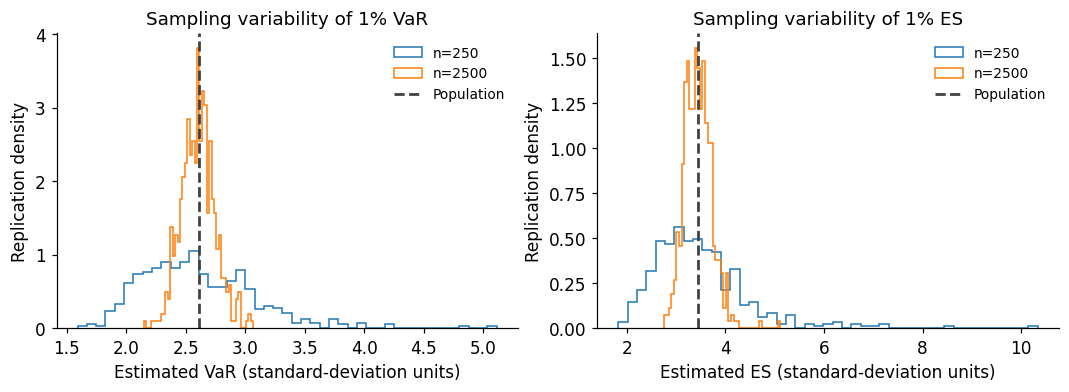

,n,measure,population,mean estimate,replication SD
0,250,VaR,2.6065,2.6024,0.4726
1,250,ES,3.4488,3.4651,0.9529
2,2500,VaR,2.6065,2.6033,0.1416
3,2500,ES,3.4488,3.4469,0.2767


In [7]:
rng_replications = np.random.default_rng(505)
alpha = .01
true_var = student_t_var(0, np.sqrt(3/5), 5, alpha)
true_es = student_t_es(0, np.sqrt(3/5), 5, alpha)
risk_replications = {}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
replication_rows = []
for n in (250, 2500):
    draws = loss_populations["Student-t₅"].rvs(size=(500, n), random_state=rng_replications)
    estimates = np.array([[historical_var(row, alpha), historical_es(row, alpha)] for row in draws])
    risk_replications[n] = estimates
    for j, (ax, name, truth) in enumerate(zip(axes, ("VaR", "ES"), (true_var, true_es))):
        ax.hist(estimates[:, j], bins=45, density=True, histtype="step", label=f"n={n}")
        replication_rows.append({"n": n, "measure": name, "population": truth,
                                 "mean estimate": estimates[:,j].mean(), "replication SD": estimates[:,j].std(ddof=1)})
for ax, name, truth in zip(axes, ("VaR", "ES"), (true_var, true_es)):
    ax.axvline(truth, color="0.25", linestyle="--", label="Population")
    ax.set(xlabel=f"Estimated {name} (standard-deviation units)", ylabel="Replication density", title=f"Sampling variability of 1% {name}")
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
display(pd.DataFrame(replication_rows).round(4))

ES depends on the magnitudes of the most extreme observations, which makes it especially sensitive to a sparse tail. Larger samples narrow the estimator distributions in this experiment. The population is known here, while real observations provide no true risk value for comparison.

More observations reduce sampling variability, but do not correct an inappropriate parametric assumption. Notebook 05 applies empirical and parametric risk descriptions to market observations, where the true distribution and population risk measures are unknown.